In [13]:
%config InlineBackend.figure_format = 'retina'

from pathlib import Path
import os
import sys
import matplotlib.pyplot as plt
import numpy as np
import time

os.environ["PYDEVD_DISABLE_FILE_VALIDATION"] = "1"

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
if str(project_root) not in sys.path:
    sys.path.append(str(project_root))

from src import load_image, population, rendering
from src.ga import GeneticAlgorithm, fitness, mutate, cross_over


In [14]:
individual = population.create_random_individual()
individual[:5]

[Triangle(x1=14, y1=221, x2=276, y2=307, x3=263, y3=180, r=5, g=8, b=169, a=246),
 Triangle(x1=256, y1=240, x2=101, y2=211, x3=123, y3=260, r=150, g=253, b=118, a=99),
 Triangle(x1=39, y1=396, x2=41, y2=85, x3=234, y3=88, r=99, g=36, b=148, a=101),
 Triangle(x1=99, y1=2, x2=287, y2=394, x3=279, y3=256, r=38, g=12, b=100, a=100),
 Triangle(x1=36, y1=310, x2=85, y2=88, x3=125, y3=335, r=150, g=147, b=50, a=160)]

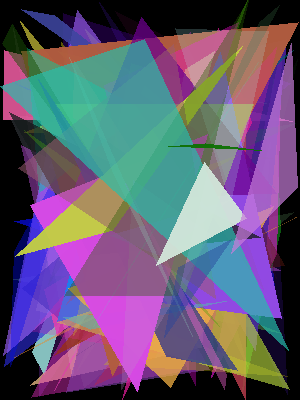

In [15]:
random_image = rendering.render_individual(individual=individual)
random_image

This random initialization confirms that the representation and rendering pipeline are functioning correctly.


In [16]:
# --- Import original paiting image --- #
image_path = os.path.join(project_root, "images/girl_pearl_earing.png")
target_array = load_image.load_target_image(image_path)
print(f"{target_array.shape} -> (H, W, 3) array with RGB values in [0, 255]")

(400, 300, 3) -> (H, W, 3) array with RGB values in [0, 255]


In [17]:
# --- Convert random first image to matrix and compute RMSE --- #
first_target_array = rendering.image_to_array(random_image)
fitness.compute_rmse(target=target_array, generated=first_target_array)

0.32877475023269653

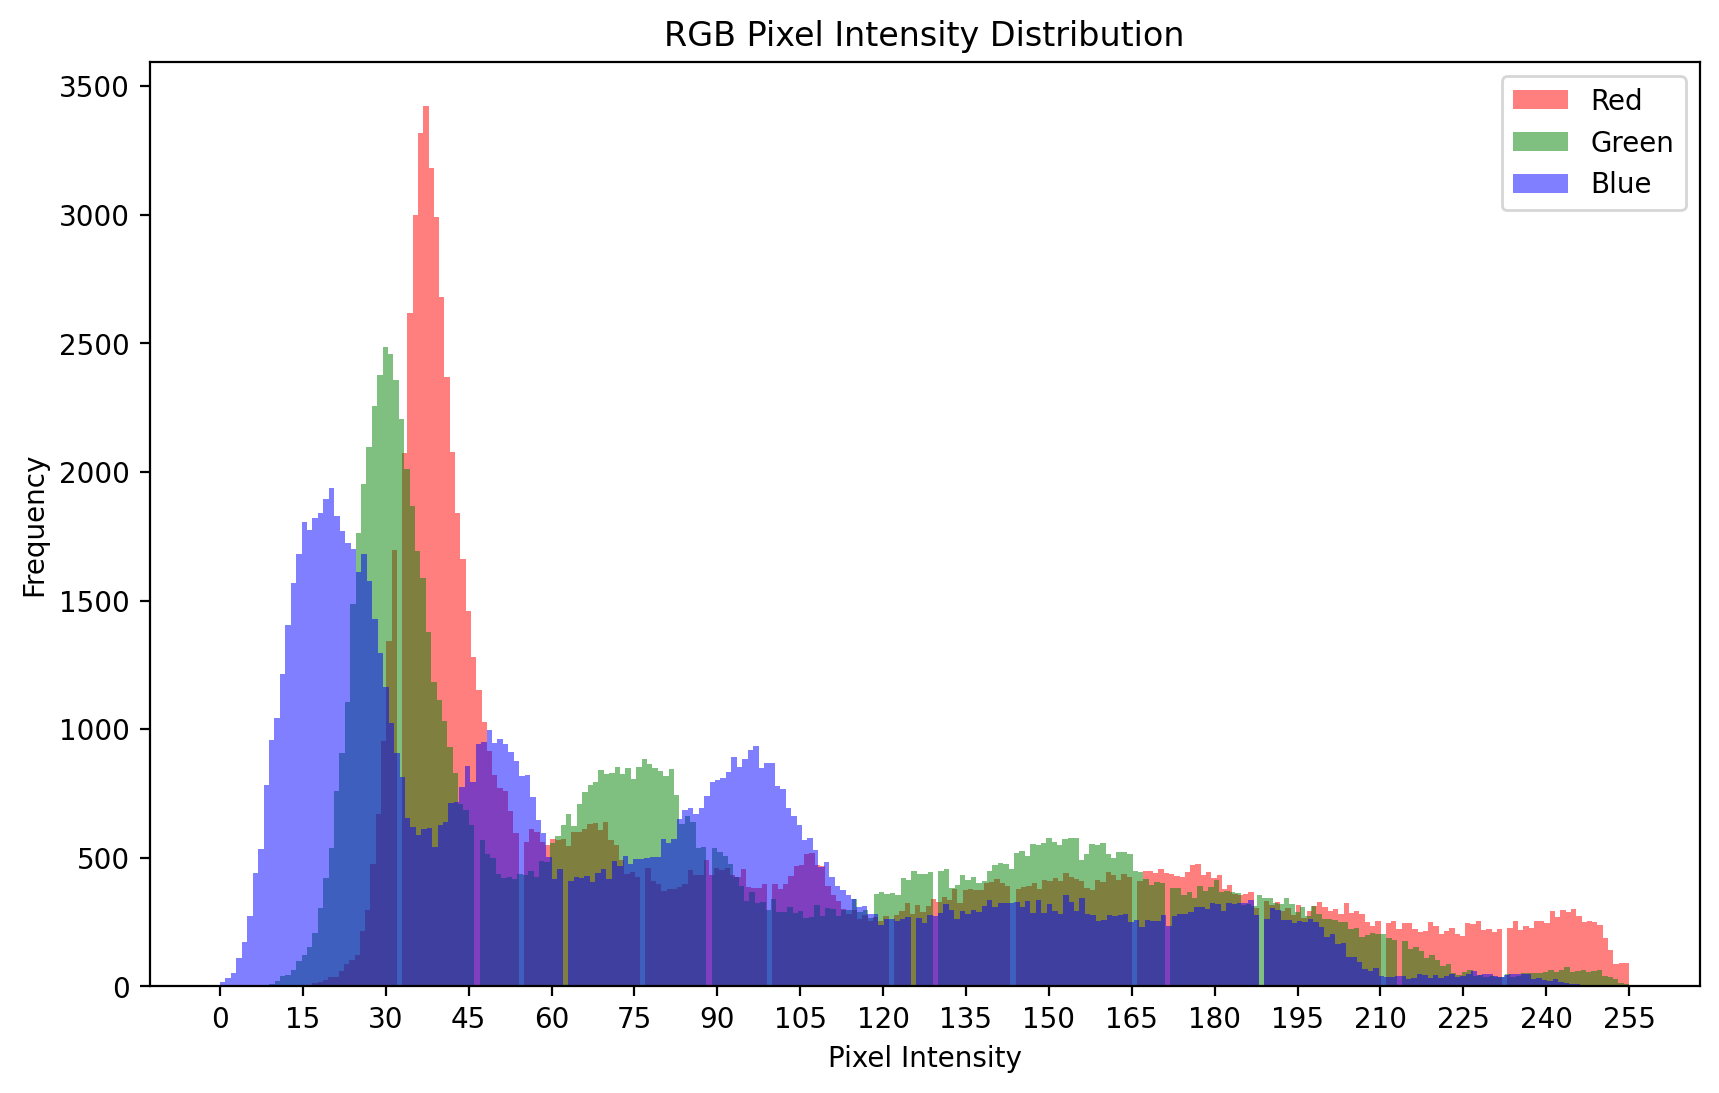

In [18]:
# Separate channels
r = target_array[:, :, 0].flatten()
g = target_array[:, :, 1].flatten()
b = target_array[:, :, 2].flatten()

# Plot histograms
plt.figure(figsize=(10, 6))
plt.hist(r, bins=256, color="red", alpha=0.5, label="Red")
plt.hist(g, bins=256, color="green", alpha=0.5, label="Green")
plt.hist(b, bins=256, color="blue", alpha=0.5, label="Blue")

plt.xticks(np.arange(0, 256, 15))  # ticks every 25
plt.xlabel("Pixel Intensity")
plt.ylabel("Frequency")
plt.title("RGB Pixel Intensity Distribution")
plt.legend()
plt.show()

# Baseline Genetic Algorithm for comparison

After initiating a random image and some triangle, we want to run a really Basic Genetic Algorithm, to have a Baseline Score, which we want to improve with further steps. 

In [ ]:
from concurrent.futures import ProcessPoolExecutor
from src.ga import save_run, fitness, mutate, cross_over
from src.ga.parallel import GAConfig, run_single_ga
from src import rendering
import matplotlib.pyplot as plt
import numpy as np
import time

N_TRIALS = 5

BASE_CONFIG = dict(
    target=target_array,
    fitness_function=fitness.compute_rmse,
    population_size=50,
    generations=100,
    crossover_function=cross_over.single_point_crossover,
    crossover_rate=0.8,
    mutation_function=mutate.random_triangle_mutation,
    mutation_rate=0.1,
    elitism=1,
    selection_type="tournament",
    triangle_alpha_range=(255, 255),
)

configs = [GAConfig(**BASE_CONFIG, trial=i, label="baseline") for i in range(N_TRIALS)]

print(f"Running {N_TRIALS} baseline trials in parallel...")
t0 = time.perf_counter()
with ProcessPoolExecutor(max_workers=N_TRIALS) as executor:
    trial_results = list(executor.map(run_single_ga, configs))
total_runtime = time.perf_counter() - t0
print(f"Done in {total_runtime:.0f}s  (vs ~{N_TRIALS * total_runtime / N_TRIALS:.0f}s sequential)")

# --- Save each trial ---
for r in trial_results:
    save_run(
        pipeline="Baseline-GA",
        parameters=r["params"],
        best_fitness=r["fitness"],
        history=r["history"],
        best_individual=r["individual"],
        runtime_seconds=r["runtime"],
        notes=f"Baseline trial {r['trial'] + 1}/{N_TRIALS}: pop=50, gen=100, single-point crossover, random mutation, elitism=1, fixed alpha=255",
        results_dir=project_root / "results" / "baseline",
    )
    print(f"  Trial {r['trial'] + 1}: RMSE={r['fitness']:.6f}  runtime={r['runtime']:.0f}s")

# --- Aggregate ---
_all_fitness    = [r["fitness"]    for r in trial_results]
_all_histories  = [r["history"]    for r in trial_results]
_all_individuals = [r["individual"] for r in trial_results]

baseline_fitness     = float(np.mean(_all_fitness))
baseline_fitness_std = float(np.std(_all_fitness))
baseline_history     = np.mean(_all_histories, axis=0).tolist()
baseline_history_std = np.std(_all_histories, axis=0)

_best_trial      = int(np.argmin(_all_fitness))
baseline_individual = _all_individuals[_best_trial]

print(f"\nBaseline GA — {N_TRIALS} trials")
print(f"  Mean RMSE : {baseline_fitness:.6f} ± {baseline_fitness_std:.6f}")
print(f"  Best      : {min(_all_fitness):.6f}  |  Worst: {max(_all_fitness):.6f}")

result_image = rendering.render_individual(
    baseline_individual,
    image_width=target_array.shape[1],
    image_height=target_array.shape[0],
)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(target_array.astype(np.uint8))
axes[0].set_title("Target")
axes[0].axis("off")
axes[1].imshow(result_image)
axes[1].set_title(f"Baseline GA — best trial  (RMSE = {min(_all_fitness):.4f})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

## Baseline GA Analysis

The following cells analyse the baseline run across five dimensions. These metrics serve as the reference point for all future improvements.

| # | Analysis | What it tells us |
|---|---|---|
| 1 | **Convergence curve** | How fast the GA improved and where it stalled |
| 2 | **Improvement statistics** | Total gain vs random, speed to 50%/90% of gain |
| 3 | **Per-channel RMSE** | Which colour channel is hardest to approximate |
| 4 | **Error heatmap** | Which image regions are spatially hardest to fit |
| 5 | **Triangle statistics** | What the GA learned about triangle size and colour |

In [ ]:
# --- 1. Convergence Curve with Annotations --- #
history = np.array(baseline_history)
hist_std = np.array(baseline_history_std)
gens = np.arange(len(history))
deltas = np.diff(history)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle("Baseline GA — Convergence Analysis (mean ± std over 5 trials)", fontweight="bold")

# Left: mean convergence curve + std band
axes[0].plot(gens, history, color="steelblue", linewidth=1.5, label="Mean RMSE")
axes[0].fill_between(gens, history - hist_std, history + hist_std, alpha=0.2, color="steelblue", label="± 1 std")
axes[0].axhline(history[-1], color="red", linestyle="--", linewidth=1, label=f"Final mean RMSE = {history[-1]:.4f}")
axes[0].axhline(history[0], color="gray", linestyle=":", linewidth=1, label=f"Gen-0 mean RMSE = {history[0]:.4f}")

best_drop_gen = int(np.argmin(deltas)) + 1
axes[0].axvline(best_drop_gen, color="orange", linestyle="--", linewidth=1,
                label=f"Biggest drop @ gen {best_drop_gen}")

axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Best fitness (RMSE)")
axes[0].set_title("Mean Convergence Curve")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# Right: per-generation mean improvement
axes[1].bar(gens[1:], -deltas, color=np.where(deltas < 0, "steelblue", "salmon"),
            width=1.0, label="Improvement (blue) / regression (red)")
axes[1].axhline(0, color="black", linewidth=0.8)
axes[1].set_xlabel("Generation")
axes[1].set_ylabel("Mean RMSE decrease")
axes[1].set_title("Per-Generation Mean Improvement")
axes[1].legend(fontsize=8)
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

In [27]:
# --- 2. Improvement Statistics --- #
history = np.array(baseline_history)
random_rmse = 0.29  # approximate RMSE of a random individual (from earlier cell)

total_improvement = random_rmse - baseline_fitness
total_improvement_pct = total_improvement / random_rmse * 100

# Generation where 50% and 90% of total gain were reached
gain_per_gen = random_rmse - history
gen_50 = next((i for i, g in enumerate(gain_per_gen) if g >= 0.5 * total_improvement), len(history) - 1)
gen_90 = next((i for i, g in enumerate(gain_per_gen) if g >= 0.9 * total_improvement), len(history) - 1)

deltas = np.diff(history)
stagnant_gens = int(np.sum(deltas == 0))
improving_gens = int(np.sum(deltas < 0))

print("=" * 50)
print("  Baseline GA — Improvement Summary")
print("=" * 50)
print(f"  Random init RMSE  : {random_rmse:.4f}")
print(f"  Final RMSE        : {baseline_fitness:.6f}")
print(f"  Total improvement : {total_improvement:.6f}  ({total_improvement_pct:.1f}%)")
print(f"  50% gain reached  : generation {gen_50}")
print(f"  90% gain reached  : generation {gen_90}")
print(f"  Improving gens    : {improving_gens} / {len(history)}")
print(f"  Stagnant gens     : {stagnant_gens} / {len(history)}")
print(f"  Avg improvement   : {-deltas[deltas < 0].mean():.6f} per improving generation")
print("=" * 50)

  Baseline GA — Improvement Summary
  Random init RMSE  : 0.2900
  Final RMSE        : 0.230940
  Total improvement : 0.059060  (20.4%)
  50% gain reached  : generation 54
  90% gain reached  : generation 90
  Improving gens    : 89 / 100
  Stagnant gens     : 10 / 100
  Avg improvement   : 0.001233 per improving generation


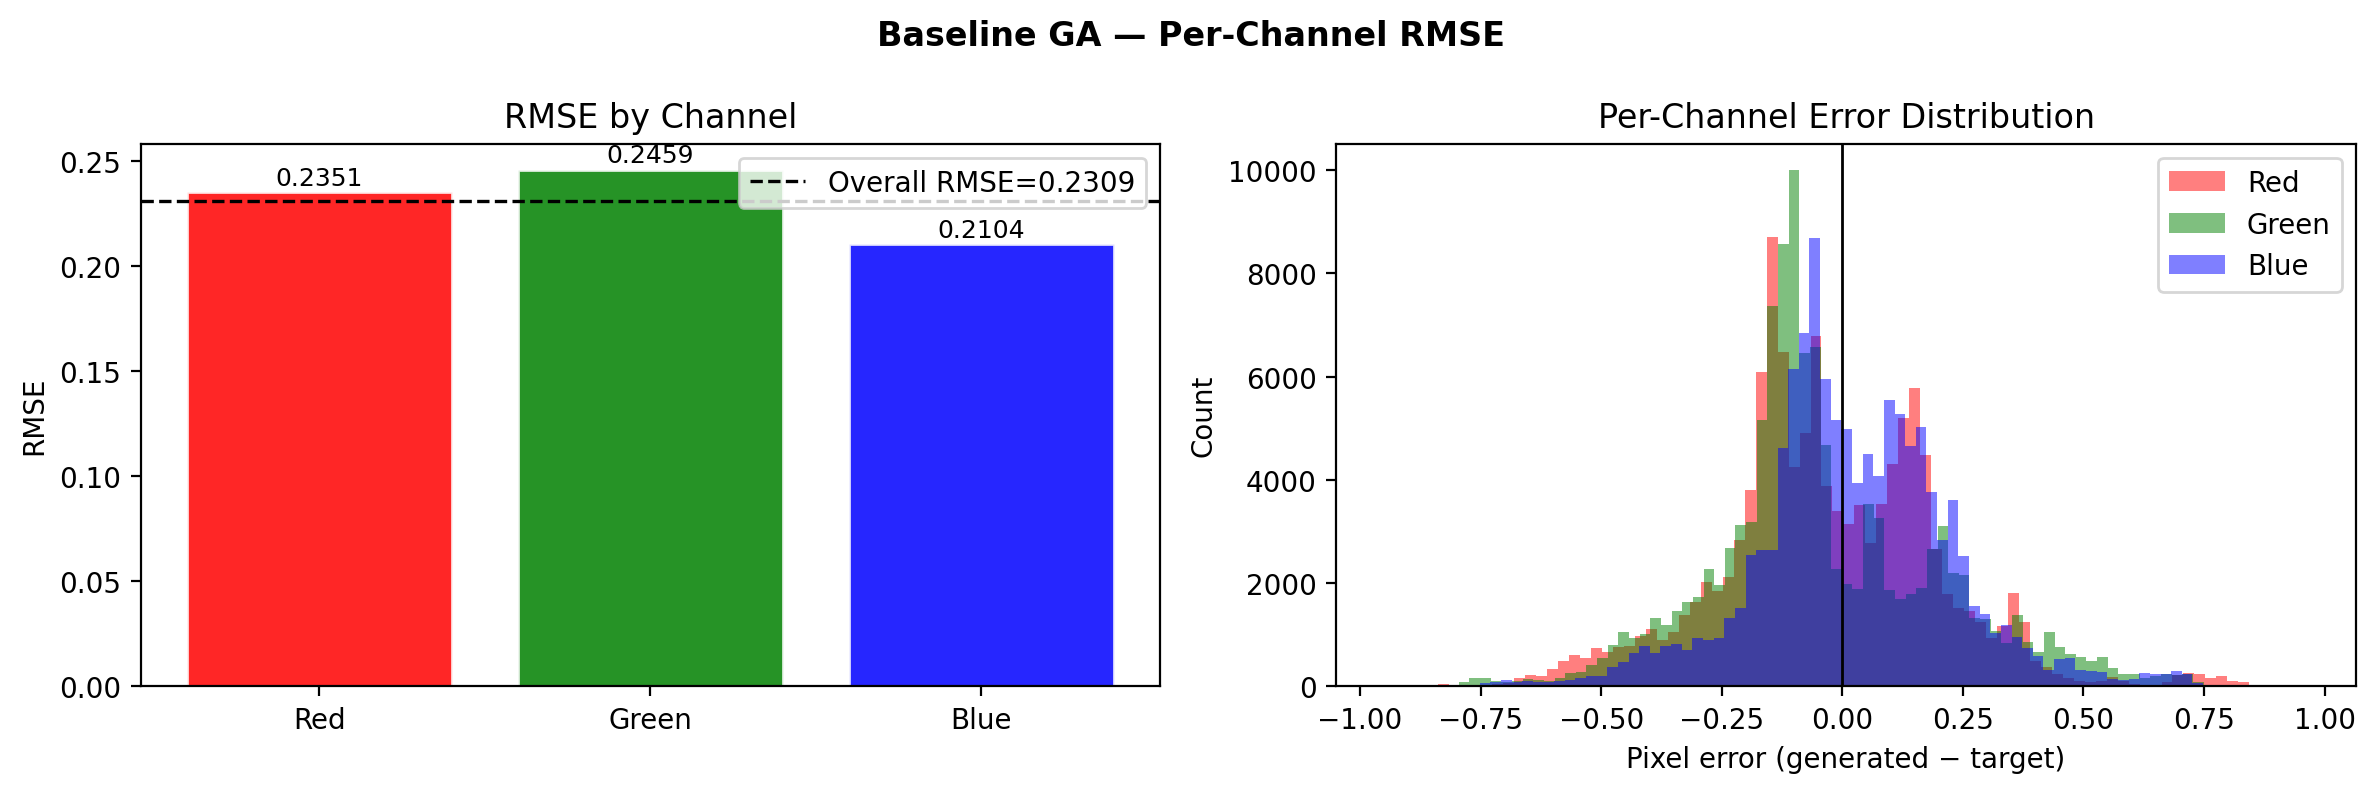

Red   RMSE: 0.235071  (above overall)
Green RMSE: 0.245901  (above overall)
Blue  RMSE: 0.210414  (below overall)


In [28]:
# --- 3. Per-Channel RMSE --- #
baseline_array_ch = rendering.image_to_array(result_image).astype(np.float32) / 255.0
target_ch = target_array.astype(np.float32) / 255.0

channel_names = ["Red", "Green", "Blue"]
channel_colors = ["red", "green", "blue"]
channel_rmse = [
    np.sqrt(np.mean((baseline_array_ch[:, :, i] - target_ch[:, :, i]) ** 2))
    for i in range(3)
]

fig, axes = plt.subplots(1, 2, figsize=(12, 4))
fig.suptitle("Baseline GA — Per-Channel RMSE", fontweight="bold")

bars = axes[0].bar(channel_names, channel_rmse, color=channel_colors, edgecolor="white", alpha=0.85)
axes[0].axhline(baseline_fitness, color="black", linestyle="--", linewidth=1.2, label=f"Overall RMSE={baseline_fitness:.4f}")
axes[0].set_ylabel("RMSE")
axes[0].set_title("RMSE by Channel")
axes[0].legend()
for bar, val in zip(bars, channel_rmse):
    axes[0].text(bar.get_x() + bar.get_width() / 2, val + 0.001, f"{val:.4f}", ha="center", va="bottom", fontsize=9)

for i, (name, color) in enumerate(zip(channel_names, channel_colors)):
    diff = (baseline_array_ch[:, :, i] - target_ch[:, :, i]).flatten()
    axes[1].hist(diff, bins=80, alpha=0.5, color=color, label=name)
axes[1].axvline(0, color="black", linewidth=1)
axes[1].set_xlabel("Pixel error (generated − target)")
axes[1].set_ylabel("Count")
axes[1].set_title("Per-Channel Error Distribution")
axes[1].legend()

plt.tight_layout()
plt.show()

for name, val in zip(channel_names, channel_rmse):
    print(f"{name:5s} RMSE: {val:.6f}  ({'above' if val > baseline_fitness else 'below'} overall)")

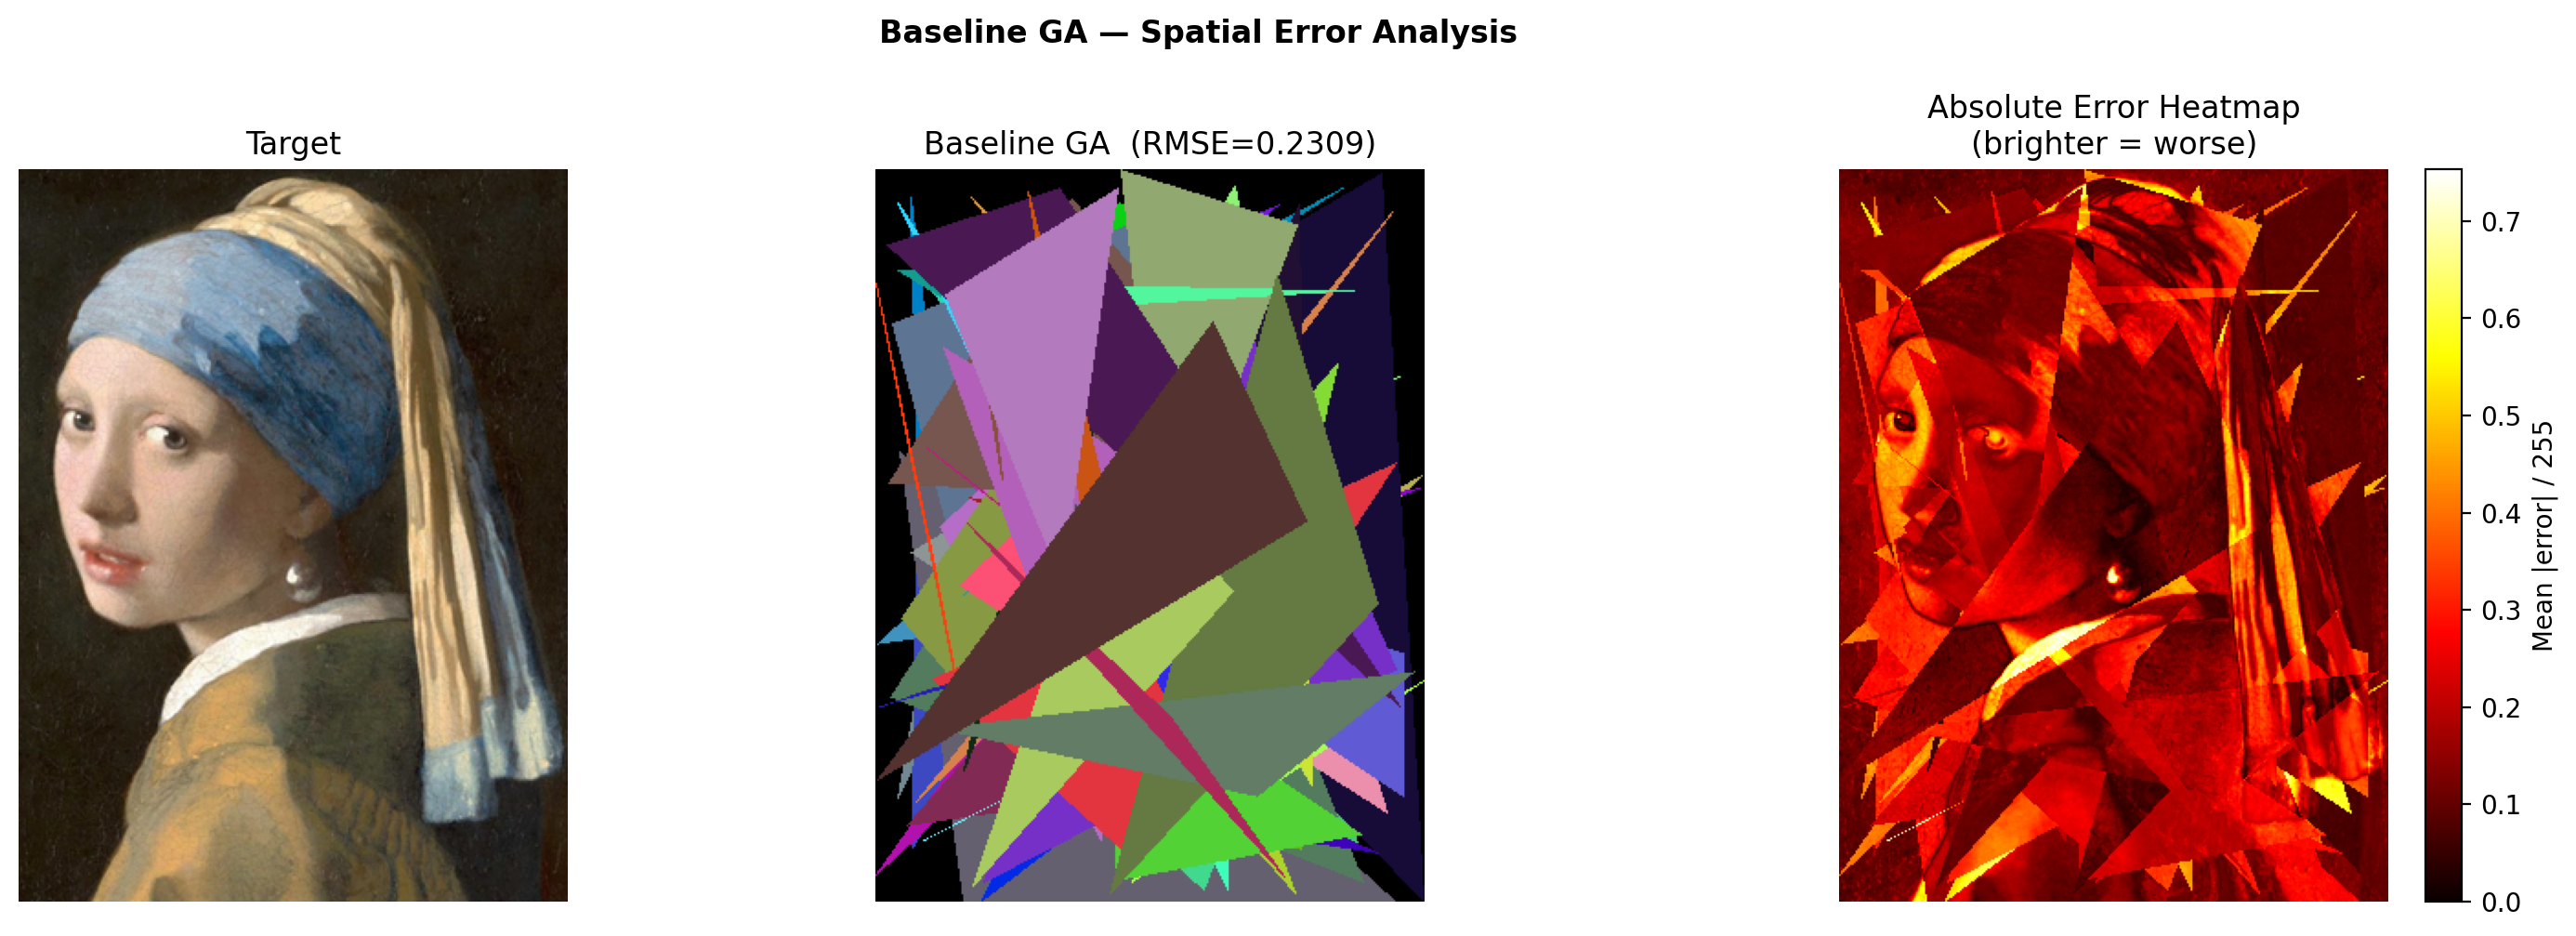

Mean pixel error : 0.1792
90th-pct error   : 0.3346  (top 10% of pixels account for most error)
Max pixel error  : 0.7529


In [29]:
# --- 4. Error Heatmap --- #
baseline_array = rendering.image_to_array(result_image).astype(np.float32)
target_f = target_array.astype(np.float32)

pixel_error = np.mean(np.abs(baseline_array - target_f), axis=2) / 255.0

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
fig.suptitle("Baseline GA — Spatial Error Analysis", fontweight="bold")

axes[0].imshow(target_array.astype(np.uint8))
axes[0].set_title("Target")
axes[0].axis("off")

axes[1].imshow(result_image)
axes[1].set_title(f"Baseline GA  (RMSE={baseline_fitness:.4f})")
axes[1].axis("off")

im = axes[2].imshow(pixel_error, cmap="hot", vmin=0, vmax=pixel_error.max())
axes[2].set_title("Absolute Error Heatmap\n(brighter = worse)")
axes[2].axis("off")
plt.colorbar(im, ax=axes[2], fraction=0.046, pad=0.04, label="Mean |error| / 255")

plt.tight_layout()
plt.show()

worst_pct = np.percentile(pixel_error, 90)
print(f"Mean pixel error : {pixel_error.mean():.4f}")
print(f"90th-pct error   : {worst_pct:.4f}  (top 10% of pixels account for most error)")
print(f"Max pixel error  : {pixel_error.max():.4f}")

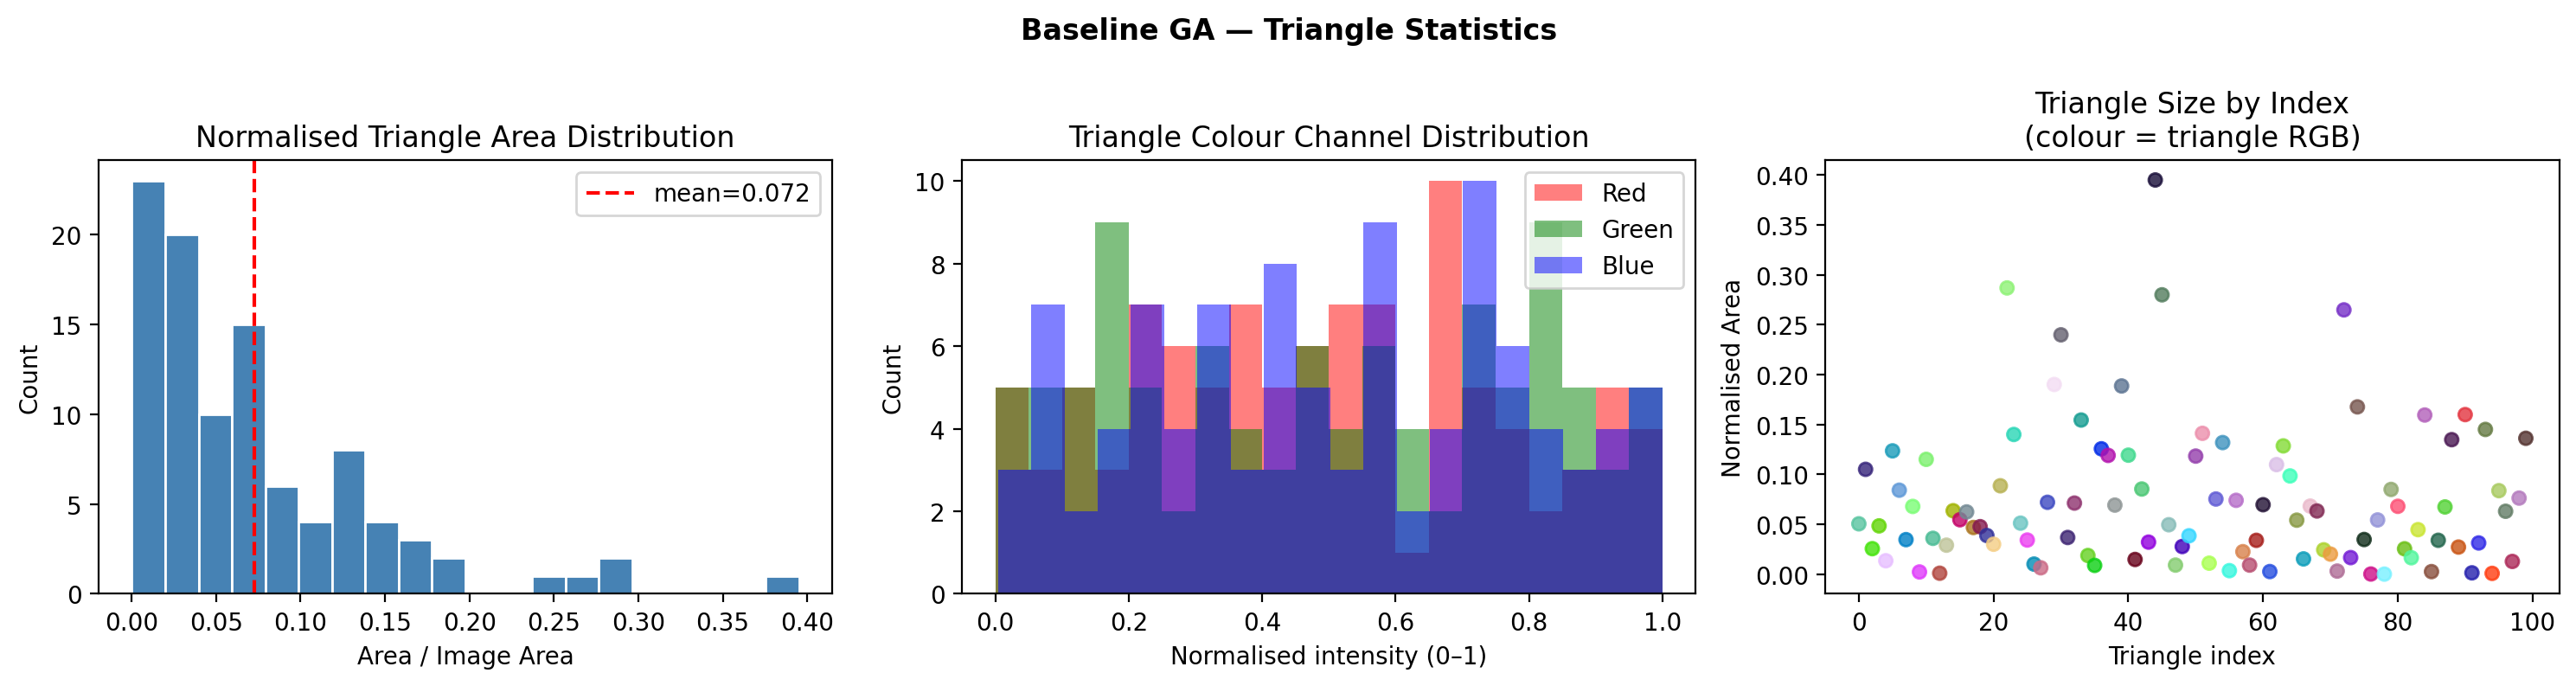

Area — mean: 0.0724  std: 0.0708  min: 0.0001  max: 0.3951
R    — mean: 0.485  G — mean: 0.498  B — mean: 0.508


In [30]:
# --- 5. Triangle Statistics --- #
triangle_areas = []
triangle_colors = []
h, w = target_array.shape[:2]

for t in baseline_individual:
    area = abs((t.x2 - t.x1) * (t.y3 - t.y1) - (t.x3 - t.x1) * (t.y2 - t.y1)) / 2
    triangle_areas.append(area / (h * w))
    triangle_colors.append((t.r / 255.0, t.g / 255.0, t.b / 255.0))

areas = np.array(triangle_areas)
colors = np.array(triangle_colors)

fig, axes = plt.subplots(1, 3, figsize=(15, 4))
fig.suptitle("Baseline GA — Triangle Statistics", fontweight="bold")

axes[0].hist(areas, bins=20, color="steelblue", edgecolor="white")
axes[0].axvline(areas.mean(), color="red", linestyle="--", label=f"mean={areas.mean():.3f}")
axes[0].set_title("Normalised Triangle Area Distribution")
axes[0].set_xlabel("Area / Image Area")
axes[0].set_ylabel("Count")
axes[0].legend()

for i, (channel, color) in enumerate(zip(["Red", "Green", "Blue"], ["red", "green", "blue"])):
    axes[1].hist(colors[:, i], bins=20, alpha=0.5, color=color, label=channel)
axes[1].set_title("Triangle Colour Channel Distribution")
axes[1].set_xlabel("Normalised intensity (0–1)")
axes[1].set_ylabel("Count")
axes[1].legend()

axes[2].scatter(range(len(areas)), areas, c=colors, s=30, alpha=0.8)
axes[2].set_title("Triangle Size by Index\n(colour = triangle RGB)")
axes[2].set_xlabel("Triangle index")
axes[2].set_ylabel("Normalised Area")

plt.tight_layout()
plt.show()

print(f"Area — mean: {areas.mean():.4f}  std: {areas.std():.4f}  min: {areas.min():.4f}  max: {areas.max():.4f}")
print(f"R    — mean: {colors[:,0].mean():.3f}  G — mean: {colors[:,1].mean():.3f}  B — mean: {colors[:,2].mean():.3f}")

# First Method : Elitism, Gridsearch, 1,2,3,4,5


In [ ]:
from concurrent.futures import ProcessPoolExecutor
from src.ga import save_run, fitness, mutate, cross_over
from src.ga.parallel import GAConfig, run_single_ga
import numpy as np
import time

N_TRIALS = 5
ELITISM_VALUES = [1, 2, 3, 4, 5]

# Build all 25 configs upfront (5 elitism values × 5 trials)
all_configs = [
    GAConfig(
        target=target_array,
        fitness_function=fitness.compute_rmse,
        population_size=50,
        generations=100,
        crossover_function=cross_over.single_point_crossover,
        crossover_rate=0.8,
        mutation_function=mutate.random_triangle_mutation,
        mutation_rate=0.1,
        elitism=e,
        selection_type="tournament",
        triangle_alpha_range=(255, 255),
        trial=t,
        label=f"elitism-{e}",
    )
    for e in ELITISM_VALUES
    for t in range(N_TRIALS)
]

print(f"Running {len(all_configs)} trials ({len(ELITISM_VALUES)} elitism values × {N_TRIALS} trials) with max_workers=5...")
t0 = time.perf_counter()
with ProcessPoolExecutor(max_workers=5) as executor:
    all_results = list(executor.map(run_single_ga, all_configs))
total_runtime = time.perf_counter() - t0
print(f"Done in {total_runtime:.0f}s")

# --- Save and aggregate ---
elitism_results = {}

for r in all_results:
    save_run(
        pipeline=f"Elitism-{r['elitism']}",
        parameters=r["params"],
        best_fitness=r["fitness"],
        history=r["history"],
        best_individual=r["individual"],
        runtime_seconds=r["runtime"],
        notes=f"Elitism grid search: elitism={r['elitism']}, trial {r['trial'] + 1}/{N_TRIALS}, all other params identical to baseline",
        results_dir=project_root / "results" / "elitism",
    )
    elitism_results.setdefault(r["elitism"], []).append(r)

# Summarise per elitism value
_aggregated = {}
for e, runs in elitism_results.items():
    fitnesses   = [r["fitness"]    for r in runs]
    histories   = [r["history"]    for r in runs]
    individuals = [r["individual"] for r in runs]
    _best = int(np.argmin(fitnesses))
    _aggregated[e] = {
        "mean_fitness" : float(np.mean(fitnesses)),
        "std_fitness"  : float(np.std(fitnesses)),
        "all_fitness"  : fitnesses,
        "mean_history" : np.mean(histories, axis=0).tolist(),
        "std_history"  : np.std(histories, axis=0),
        "individual"   : individuals[_best],
    }
    print(f"  Elitism={e} — mean RMSE: {_aggregated[e]['mean_fitness']:.6f} ± {_aggregated[e]['std_fitness']:.6f}")

elitism_results = _aggregated
print("\nGrid search complete.")

In [ ]:
import matplotlib.pyplot as plt
import numpy as np

colors_map = plt.cm.tab10.colors
elitism_values = sorted(elitism_results.keys())

# ── 1. Convergence curves with std bands ──────────────────────────────────────
fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle("Elitism Grid Search — Analysis (mean ± std over 5 trials)", fontweight="bold")

for i, e in enumerate(elitism_values):
    h   = np.array(elitism_results[e]["mean_history"])
    std = np.array(elitism_results[e]["std_history"])
    label = f"elitism={e}  ({elitism_results[e]['mean_fitness']:.4f} ± {elitism_results[e]['std_fitness']:.4f})"
    axes[0].plot(h, color=colors_map[i], linewidth=1.5, label=label)
    axes[0].fill_between(range(len(h)), h - std, h + std, alpha=0.15, color=colors_map[i])

axes[0].axhline(baseline_fitness, color="black", linestyle="--", linewidth=1.2,
                label=f"Baseline mean RMSE={baseline_fitness:.4f}")
axes[0].set_xlabel("Generation")
axes[0].set_ylabel("Best fitness (RMSE)")
axes[0].set_title("Mean Convergence Curves (shaded = ± 1 std)")
axes[0].legend(fontsize=8)
axes[0].grid(True, alpha=0.3)

# ── 2. Bar chart with error bars ──────────────────────────────────────────────
means = [elitism_results[e]["mean_fitness"] for e in elitism_values]
stds  = [elitism_results[e]["std_fitness"]  for e in elitism_values]

bars = axes[1].bar(
    [str(e) for e in elitism_values],
    means,
    yerr=stds,
    capsize=5,
    color=[colors_map[i] for i in range(len(elitism_values))],
    edgecolor="white",
    error_kw={"elinewidth": 1.5, "ecolor": "black"},
)
axes[1].axhline(baseline_fitness, color="black", linestyle="--", linewidth=1.2,
                label=f"Baseline mean RMSE={baseline_fitness:.4f}")
axes[1].set_xlabel("Elitism value")
axes[1].set_ylabel("Mean final RMSE")
axes[1].set_title("Mean Final RMSE ± std by Elitism Value")
axes[1].legend(fontsize=8)
for bar, mean, std in zip(bars, means, stds):
    axes[1].text(bar.get_x() + bar.get_width() / 2, mean + std + 0.001,
                 f"{mean:.4f}", ha="center", va="bottom", fontsize=8)

plt.tight_layout()
plt.show()

# ── 3. Summary table ──────────────────────────────────────────────────────────
best_elitism = min(elitism_results, key=lambda e: elitism_results[e]["mean_fitness"])

print("=" * 72)
print("  Elitism Grid Search — Summary (5 trials each)")
print("=" * 72)
print(f"  {'Elitism':>8}  {'Mean RMSE':>10}  {'± Std':>8}  {'vs Baseline':>12}  {'Min':>10}  {'Max':>10}")
print(f"  {'-'*8}  {'-'*10}  {'-'*8}  {'-'*12}  {'-'*10}  {'-'*10}")
for e in elitism_values:
    r     = elitism_results[e]
    delta = r["mean_fitness"] - baseline_fitness
    sign  = "+" if delta > 0 else ""
    marker = " <-- best" if e == best_elitism else ""
    print(f"  {e:>8}  {r['mean_fitness']:>10.6f}  {r['std_fitness']:>8.6f}  {sign}{delta:>11.6f}  {min(r['all_fitness']):>10.6f}  {max(r['all_fitness']):>10.6f}{marker}")
print("=" * 72)
print(f"\n  Best elitism value : {best_elitism}  (mean RMSE = {elitism_results[best_elitism]['mean_fitness']:.6f} ± {elitism_results[best_elitism]['std_fitness']:.6f})")

# More Detailled Analysis

In [ ]:
from src.ga import save_run


ga = GeneticAlgorithm(
    target=target_array,
    triangle_alpha_range=(255, 255),
    fitness_function=fitness.compute_rmse,
    population_size=100,
    generations=100,
    crossover_function=cross_over.two_point_crossover,
    crossover_rate=0.85,
    mutation_function=mutate.focused_triangle_mutation,
    mutation_rate=0.12,
    elitism=5,
    selection_type="tournament",
    adaptive_mutation=True,
    mutation_rate_bounds=(0.05, 0.22),
    stagnation_window=15,
    random_immigrants=5,
    initial_population=None,
    local_search_steps=30,
    logs=True,
    evaluation_backend="process",
    n_jobs=8,
    chunksize=5,
    progress=True,
    progress_interval=10,
)

t0 = time.perf_counter()
best_fitness, history = ga.run()
runtime = time.perf_counter() - t0
best_individual = ga.best_individual

save_run(
    pipeline="GA",
    parameters=ga.params_dict(),
    best_fitness=best_fitness,
    history=history,
    best_individual=best_individual,
    runtime_seconds=runtime,
    notes="GA with random init, focused mutation, local search, adaptive mutation",
)

print(f"GA best fitness (RMSE): {best_fitness:.6f}  |  runtime: {runtime:.0f}s")

result_image = rendering.render_individual(
    best_individual,
    image_width=target_array.shape[1],
    image_height=target_array.shape[0],
)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(target_array.astype(np.uint8))
axes[0].set_title("Target")
axes[0].axis("off")
axes[1].imshow(result_image)
axes[1].set_title(f"GA result  (RMSE = {best_fitness:.4f})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
# Output the best fitness and display the best individual's image
print(f"Best Fitness: {best_fitness}")

In [ ]:
rendering.render_individual(individual=ga.best_individual)

In [ ]:
from src.ga import LegacyPipelineConfig, run_legacy_pipeline, fitness

project_root = Path.cwd().parent if Path.cwd().name == "notebooks" else Path.cwd()
image_path = project_root / "images/girl_pearl_earing.png"  # change if needed
target_image = load_image.load_target_image(image_path)

legacy_config = LegacyPipelineConfig(
    population_size=200,
    generations=400,
    n_triangles=100,
    elitism_fraction=0.2,
    tournament_size=3,
    mutation_rate=0.15,
    position_sigma=0.05,
    color_sigma=0.08,
    stagnation_boost_window=15,
    diversity_window=30,
    local_search_steps=50,
    evaluation_backend="process",  # or "sequential" / "thread"
    n_jobs=8,
    chunksize=8,
    seed=42,
    progress=True,
    progress_interval=10,
)

legacy_result = run_legacy_pipeline(
    target=target_image,
    config=legacy_config,
    fitness_function=fitness.compute_rmse,
)

best_fitness = legacy_result.best_fitness
history = legacy_result.history
best_individual = legacy_result.best_individual
generation_logs = legacy_result.generation_logs

In [ ]:
from src.ga import HybridPSOGA, create_greedy_seeded_population, save_run, fitness, mutate, cross_over
from src import rendering
import matplotlib.pyplot as plt
import numpy as np
import time

greedy_population = create_greedy_seeded_population(
    target=target_array,
    population_size=200,
    n_triangles=100,
    image_width=300,
    image_height=400,
    candidates_per_triangle=200,
    verbose=True,
)

pso_ga = HybridPSOGA(
    target=target_array,
    fitness_function=fitness.compute_rmse,
    population_size=200,
    generations=300,
    n_triangles=100,
    inertia=0.9,
    inertia_min=0.4,
    c1=1.5,
    c2=1.5,
    crossover_function=cross_over.two_point_crossover,
    crossover_rate=0.7,
    mutation_function=mutate.focused_triangle_mutation,
    mutation_rate=0.08,
    local_search_steps=30,
    initial_population=greedy_population,
    evaluation_backend="process",
    n_jobs=8,
    chunksize=5,
    progress=True,
    progress_interval=10,
)

t0 = time.perf_counter()
pso_result = pso_ga.run()
runtime = time.perf_counter() - t0

save_run(
    pipeline="PSO-GA",
    parameters=pso_ga.params_dict(),
    best_fitness=pso_result.best_fitness,
    history=pso_result.history,
    best_individual=pso_result.best_individual,
    runtime_seconds=runtime,
    notes="Hybrid PSO-GA with greedy init and focused mutation",
)

print(f"PSO-GA best fitness (RMSE): {pso_result.best_fitness:.6f}  |  runtime: {runtime:.0f}s")

result_image = rendering.render_individual(
    pso_result.best_individual,
    image_width=target_array.shape[1],
    image_height=target_array.shape[0],
)

fig, axes = plt.subplots(1, 2, figsize=(10, 6))
axes[0].imshow(target_array.astype(np.uint8))
axes[0].set_title("Target")
axes[0].axis("off")
axes[1].imshow(result_image)
axes[1].set_title(f"PSO-GA result  (RMSE = {pso_result.best_fitness:.4f})")
axes[1].axis("off")
plt.tight_layout()
plt.show()

In [ ]:
from src.ga import load_all_runs, runs_dataframe
from src import rendering
import matplotlib.pyplot as plt
import numpy as np

# ── Load all saved runs ───────────────────────────────────────────────────────
runs = load_all_runs()
df = runs_dataframe()

if df.empty:
    print("No saved runs yet. Run the GA or PSO-GA cell first.")
else:
    # ── Summary table ─────────────────────────────────────────────────────────
    summary_cols = ["run_id", "pipeline", "best_fitness", "generations_run", "runtime_seconds", "notes"]
    available = [c for c in summary_cols if c in df.columns]
    print("=== All runs ===")
    print(df[available].to_string(index=False))

    # ── Convergence curves ────────────────────────────────────────────────────
    fig, ax = plt.subplots(figsize=(12, 5))
    for run in runs:
        label = f"{run['pipeline']}  RMSE={run['results']['best_fitness']:.4f}  ({run['run_id'][-15:]})"
        ax.plot(run["results"]["history"], label=label)
    ax.set_xlabel("Generation")
    ax.set_ylabel("Best fitness (RMSE)")
    ax.set_title("Convergence — all runs")
    ax.legend(fontsize=8)
    ax.grid(True)
    plt.tight_layout()
    plt.show()

    # ── Best result images ────────────────────────────────────────────────────
    target_array_local = target_array if "target_array" in dir() else None
    if target_array_local is not None:
        n = len(runs)
        fig, axes = plt.subplots(1, n + 1, figsize=(5 * (n + 1), 5))
        axes[0].imshow(target_array_local.astype(np.uint8))
        axes[0].set_title("Target")
        axes[0].axis("off")
        for i, run in enumerate(runs):
            img = rendering.render_individual(
                run["individual"],
                image_width=target_array_local.shape[1],
                image_height=target_array_local.shape[0],
            )
            axes[i + 1].imshow(img)
            axes[i + 1].set_title(f"{run['pipeline']}\nRMSE={run['results']['best_fitness']:.4f}", fontsize=9)
            axes[i + 1].axis("off")
        plt.tight_layout()
        plt.show()